Testing The Script

In [ ]:
import numpy as np
from itertools import combinations
from tqdm import tqdm
# Translated originally form Julia Code, we generate adinkras via cubical cohomology

def generate_code(generator):
    d = len(generator)
    N = len(generator[0])
    
    # collect all combinations of length 1..d
    combs = []
    for dd in range(1, d+1):
        combs.extend(combinations(generator, dd))
    
    code = []
    for str_tuple in combs:
        # XOR all vectors in the tuple
        acc = str_tuple[0].copy()
        for vec in str_tuple[1:]:
            acc = np.bitwise_xor(acc, vec)
        code.append(acc)
    
    # prepend the zero vector
    code.insert(0, np.zeros(N, dtype=np.uint8))
    return code


def decode_ncube_signed(generator, allow_large_computations=False):
    d = len(generator)
    N = len(generator[0])
    
    if N >= 16 and not allow_large_computations:
        return "Are You Sure?"
    
    code = generate_code(generator)
    
    # NCubeIndexMap = [1, 2, ..., 2^N]
    NCubeIndexMap = list(range(1, 2**N + 1))
    
    # NCubeLattice = all binary vectors of length N
    NCubeLattice = [np.array(list(map(int, np.binary_repr(nn, width=N))), dtype=np.uint8)
                    for nn in range(2**N)]
    
    # Basis = standard basis vectors
    Basis = [np.array(list(map(int, np.binary_repr(1 << nn, width=N))), dtype=np.uint8)
             for nn in range(N)]
    
    Partitioned = []
    for _ in tqdm(range(2**(N-d))):
        # apply XOR with each codeword
        new_partition = [np.bitwise_xor(NCubeLattice[0], c) for c in code]
        Partitioned.append(new_partition)
        
        for point in new_partition:
            idx = int(np.dot(point, 2**np.arange(N-1, -1, -1))) + 1
            # delete corresponding lattice point
            del NCubeLattice[NCubeIndexMap[idx-1]-1]
            NCubeIndexMap[idx-1] = 0
            for i in range(idx, len(NCubeIndexMap)):
                NCubeIndexMap[i] -= 1
    
    # Adjacency structure
    Adjacency = [[np.zeros(2**(N-d), dtype=np.uint8) for _ in range(2**(N-d))]
                  for _ in range(N)]
    
    for hi, basis_vec in tqdm(enumerate(Basis),total = len(Basis)):
        for hj in range(2**(N-d)):
            newstr = np.bitwise_xor(Partitioned[hj][0], basis_vec)
            for hk in range(2**(N-d)):
                if any(np.array_equal(newstr, p) for p in Partitioned[hk]):
                    Adjacency[hi][hj][hk] = 1
                    break
    
    # Build adjacency matrices
    AdjacencyC = [np.vstack([np.transpose(np.array(layer, dtype=np.uint8)) 
                             for layer in Adjacency[i]])
                  for i in range(N)]
    
    # Sum all adjacency matrices elementwise
    AdjacencyM = np.zeros_like(AdjacencyC[0])
    for A in AdjacencyC:
        AdjacencyM += A

    return(AdjacencyC,AdjacencyM)

In [3]:
RM_2_4 = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
[0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
[0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1],
[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]]


In [ ]:
adjc, adj = decode_ncube_signed(RM_2_4, allow_large_computations=True)

100%|██████████| 16/16 [00:27<00:00,  1.74s/it]


In [17]:
print(adj)


[[0 1 1 ... 0 0 1]
 [1 0 0 ... 1 1 0]
 [1 0 0 ... 1 1 0]
 ...
 [0 1 1 ... 0 0 1]
 [0 1 1 ... 0 0 1]
 [1 0 0 ... 1 1 0]]


In [18]:
import numpy as np
import networkx as nx

def get_distance_matrix(adjacencyC):
    """
    Compute the distance matrix of a graph defined by adjacency matrices (AdjacencyC).
    
    Parameters
    ----------
    adjacencyC : list of np.ndarray
        List of adjacency matrices (square, binary).
    
    Returns
    -------
    dm : np.ndarray
        Distance matrix (num_vertices x num_vertices).
    """
    n = adjacencyC[0].shape[0]
    
    # --- Build edge set ---
    edges = set()
    for mt in adjacencyC:
        # neighbors for each row
        oneline = mt @ np.arange(1, n+1)   # same as Julia's mt*[1..n]
        for i, val in enumerate(oneline):
            if val > 0:   # has neighbor(s)
                # Find all j such that edge exists
                neighbors = np.where(mt[i] > 0)[0]
                for j in neighbors:
                    edge = tuple(sorted((i, j)))
                    if edge[0] != edge[1]:
                        edges.add(edge)
    
    # --- Build graph ---
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(edges)
    
    # --- Compute all-pairs shortest paths ---
    dist = dict(nx.all_pairs_shortest_path_length(G))
    
    # Convert to numpy matrix
    dm = np.full((n, n), np.inf)
    for i in range(n):
        dm[i, i] = 0
        for j, d in dist[i].items():
            dm[i, j] = d
    
    return dm.astype(int)


In [19]:
dm = get_distance_matrix(adjc)
print(dm)

[[0 1 1 ... 2 2 1]
 [1 0 2 ... 1 1 2]
 [1 2 0 ... 1 1 2]
 ...
 [2 1 1 ... 0 2 1]
 [2 1 1 ... 2 0 1]
 [1 2 2 ... 1 1 0]]


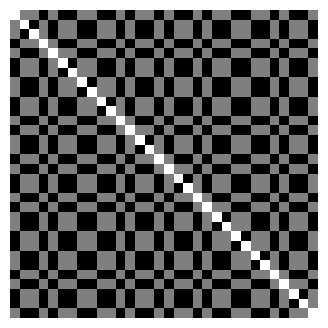

In [21]:
distance_matrix_plot(dm)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def distance_matrix_plot(distM):
    """
    Plot a distance matrix as a black/white heatmap (white=low, black=high).
    
    Parameters
    ----------
    distM : np.ndarray
        Distance matrix.
    """
    miv = np.min(distM)
    mav = np.max(distM)
    
    # Colormap: white → black, midpoint at (miv + mav)/2
    midpoint = miv + (mav - miv) / 2
    cmap = LinearSegmentedColormap.from_list("bw_map", ["white", "black"])
    
    plt.figure(figsize=(4, 4))
    im = plt.imshow(distM, cmap=cmap, vmin=miv, vmax=mav, origin='upper')
    plt.axis("off")   # hide axes
    plt.box(True)     # frame box, like Julia's framestyle=:box
    plt.show()
